<a href="https://colab.research.google.com/github/salahibra/computer_vision/blob/main/06_classifiy_cats_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP : Chaîne Complète de Classification Chiens vs Chats

Dans cette séance, vous mettez en œuvre l'intégralité d'un pipeline de vision par ordinateur pour distinguer des images de chats et de chiens. Depuis la préparation des données jusqu'à l'évaluation finale d'un réseau convolutionnel, chaque activité vous invite à justifier les choix d'implémentation et à analyser l'effet des hyperparamètres sur la qualité de généralisation.


### Télécharger `dog-and-cat-classification-dataset`

<p style="color: gray">Note : Kaggle est une plateforme communautaire dédiée au data science et au machine learning, hébergeant des milliers de jeux de données publics, des compétitions et des notebooks collaboratifs. Elle permet aux praticiens d'accéder facilement à des corpus annotés, de partager leurs expériences et de progresser collectivement dans l'analyse de données et la construction de modèles prédictifs.</p>

- Télécharger le dataset "dog-and-cat-classification-dataset" depuis Kaggle en utilisant la bibliothèque `kagglehub`.
- Afficher le chemin local où les fichiers du dataset ont été sauvegardés.
- Créer la variable `images_dir` qui contient les sous-dossiers d'images
- Explorer le dossier d’images téléchargé (`PetImages`) et affiche pour chaque sous-dossier (Cat/Dog) le nombre de fichiers qu’il contient.


In [ ]:
# !pip install kagglehub

In [ ]:
import os
import kagglehub

root_dir = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", root_dir)

# Le chemin vers le dossier d'images (nommé "PetImages" dans ce dataset)
images_dir = os.path.join(root_dir, "PetImages")

print(f"Contents of {os.path.basename(images_dir)}")
for item in os.listdir(images_dir):
    item_path = os.path.join(images_dir, item)
    if os.path.isdir(item_path):
        num_files = len(os.listdir(item_path))
        print(f"  {item}/ - {num_files} files")
    else:
        print(f"  {item}")

Path to dataset files: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1
Contents of PetImages
  Dog/ - 12499 files
  Cat/ - 12499 files


### Préparer l'environnement logiciel
Importez les bibliothèques nécessaires au projet.
- Manipulation de fichiers : `os`, `glob`
- Sélection aléatoire : `random`
- Encodage des labels : `sklearn.preprocessing.LabelEncoder`
- Chargement d'images : `PIL.Image`
- Calcul scientifique : `numpy`, `pandas`
- Visualisation : `matplotlib`
- Construction du modèle : `torch`, `torch.nn`, `torch.utils.data`
- Suivi de l'entraînement : `tqdm.auto`
- Data augmentation : `albumentations`
- Séparation des jeux de données : `sklearn.model_selection.train_test_split`

In [ ]:
import os
import random
from glob import glob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import albumentations as A
from tqdm.auto import tqdm

### Encoder les catégories

Un `LabelEncoder` est un outil de la bibliothèque `scikit-learn` qui transforme des catégories textuelles (ou autres types non numériques) en valeurs numériques entières. Il est particulièrement utile quand la liste des classes est longue (ce qui n'est pas le cas ici, mais nous sommes là pour apprendre ;)

**Fonctionnement :**
- **`.fit()`** : analyse les catégories uniques présentes dans les données
- **`.transform()`** : convertit les labels textuels en indices numériques (0, 1, 2, ...)
- **`.inverse_transform()`** : effectue la transformation inverse, des indices vers les labels originaux

**Exemple :** Pour les classes `['Cat', 'Dog']`, le `LabelEncoder` associe automatiquement `Cat → 0` et `Dog → 1`, garantissant ainsi une représentation cohérente et exploitable par les modèles de classification.

Initialisez un `LabelEncoder` sur les classes textuelles "Cat" et "Dog", puis affichez la correspondance entre libellés et indices afin d'assurer une cohérence lors de la création des étiquettes numériques.

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(['Cat', 'Dog'])
print('Liste des classes:', label_encoder.classes_)
print("Exemple d'encodage:", label_encoder.transform(['Dog', 'Cat', 'Cat', 'Dog', 'Dog', 'Cat']))
print('Exemple de transformation inverse (récupération des labels):', label_encoder.inverse_transform([1, 0, 0, 1, 1, 0]))

Liste des classes: ['Cat' 'Dog']
Exemple d'encodage: [1 0 0 1 1 0]
Exemple de transformation inverse (récupération des labels): ['Dog' 'Cat' 'Cat' 'Dog' 'Dog' 'Cat']


### Construire le référentiel des données

- Définir `MAX_SAMPLES_PER_CLASS` pour limiter le nombre d'images par catégorie
- Utiliser `glob` pour récupérer les chemins des fichiers `.jpg` dans le sous-dossier `Cat`
- Utiliser `glob` pour récupérer les chemins des fichiers `.jpg` dans le sous-dossier `Dog`
- Limiter chaque liste à `MAX_SAMPLES_PER_CLASS` échantillons
- Concaténer les deux listes pour obtenir `all_files`
- Créer une liste `all_labels` répétant l'indice de `Cat` pour tous les fichiers de chats, puis l'indice de `Dog` pour tous les fichiers de chiens (utilisez `label_encoder`)
- Construire un `DataFrame` pandas nommé `df` avec les colonnes `file_path` et `label`
- Afficher le nombre total de fichiers avec `len(df)`
- Afficher les premières lignes du `DataFrame` avec `display(df.head())`


In [ ]:
MAX_SAMPLES_PER_CLASS = 1000

cat_files = glob(os.path.join(images_dir, 'Cat', '*.jpg'))[:MAX_SAMPLES_PER_CLASS]
dog_files = glob(os.path.join(images_dir, 'Dog', '*.jpg'))[:MAX_SAMPLES_PER_CLASS]
all_files = cat_files + dog_files
cat_label = label_encoder.transform(['Cat'])[0]
dog_label = label_encoder.transform(['Dog'])[0]
all_labels = [cat_label] * len(cat_files) + [dog_label] * len(dog_files)
df = pd.DataFrame({'file_path': all_files, 'label': all_labels}, columns=['file_path', 'label'])
print("Total files:", len(df))
display(df.head())
print("\nDistribution des labels:")
print(df['label'].value_counts())

Total files: 2000


,file_path,label
0,/root/.cache/kagglehub/datasets/bhavikjikadara...,0
1,/root/.cache/kagglehub/datasets/bhavikjikadara...,0
2,/root/.cache/kagglehub/datasets/bhavikjikadara...,0
3,/root/.cache/kagglehub/datasets/bhavikjikadara...,0
4,/root/.cache/kagglehub/datasets/bhavikjikadara...,0



Distribution des labels:
label
0    1000
1    1000
Name: count, dtype: int64


### Implémenter la classe `CatsDogsDataset`
Rédigez la classe `CatsDogsDataset(root_dir, dataframe, transform=None)` en précisant :

- **Constructeur (`__init__`)** :
    - Stocke les chemins des images (`root_dir` et `dataframe`).
    - Accepte une transformation optionnelle (`transform`).

- **Méthode `__len__(self)`** :
    - Retourne la taille du corpus, c'est-à-dire le nombre d'images dans le `dataframe`.

- **Méthode `__getitem__(self, idx)`** :
    - Charge l'image à partir du chemin spécifié dans le `dataframe` en utilisant `PIL.Image`.
    - Uniformise l'image en RGB et redimensionne à 128×128 pixels.
    - Applique la transformation si fournie.
    - Renvoie le couple `(image, label)` où `label` est extrait du `dataframe`.


Instanciez `CatsDogsDataset` dans `full_dataset`avec le répertoire racine et le `DataFrame` précédemment construits.

In [ ]:
class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, dataframe, transform=None):
        super().__init__()
        self.root_dir = root_dir
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['file_path'])
        img = img.resize((128, 128))
        img = img.convert("RGB")
        img = np.array(img)

        if self.transform:
            img = self.transform(image=img)['image']
        return img, row['label']

full_dataset = CatsDogsDataset(root_dir=images_dir, dataframe=df)
print("Dataset size:", len(full_dataset))

# Afficher un échantillon
sample_img, sample_label = full_dataset[0]
sample_label_str = label_encoder.inverse_transform([sample_label])[0]
print(f"Sample data image shape: {sample_img.shape}, label: {sample_label} ({sample_label_str})")

Dataset size: 2000
Sample data image shape: (128, 128, 3), label: 0 (Cat)


### Examiner la diversité des données

Créer une figure pour afficher 8 images en 2 lignes de 4 colonnes :
- Boucler pour sélectionner aléatoirement un indice dans `full_dataset` avec `random.randint()`
- Charger l'image et le label correspondants
- Afficher l'image
- Convertir le label numérique en texte
- Définir le titre de chaque image


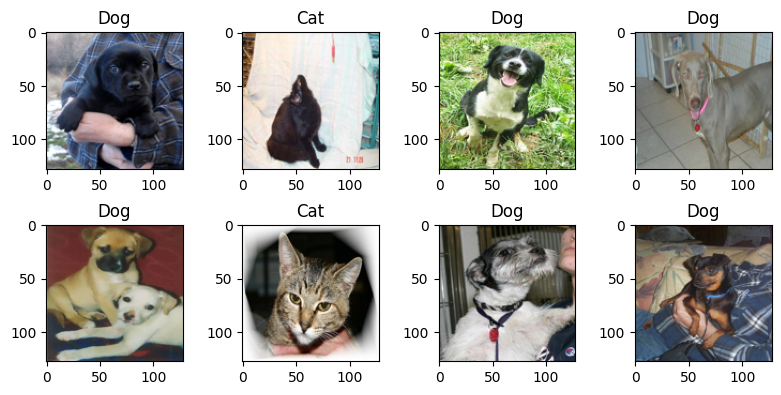

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.ravel()

for i in range(8):
    idx = random.randint(0, len(full_dataset) - 1)
    img, label = full_dataset[idx]
    axes[i].imshow(img)
    axes[i].set_title(f"{label_encoder.inverse_transform([label])[0]}")
    #axes[i].axis('off')

plt.tight_layout()
plt.show()

### Séparer apprentissage, validation et test

Exploitez `train_test_split` de `scikit-learn` pour diviser le `DataFrame` en trois ensembles :
- **Premier split** : séparez `df` en `train_val_df` (80 %) et `test_df` (20 %) avec `test_size=0.2`, `random_state=42` et `stratify=df['label']` pour conserver la proportion des classes.
- **Second split** : divisez `train_val_df` en `train_df` (60 % du total) et `val_df` (20 % du total) avec `test_size=0.25` (car 0.25 × 0.8 = 0.2), `random_state=42` et `stratify=train_val_df['label']`.
- Affichez le nombre d'échantillons dans chaque ensemble avec `len(train_df)`, `len(val_df)` et `len(test_df)` pour vérifier la répartition finale (approximativement 60 % / 20 % / 20 %).


In [ ]:
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['label'])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 1280
Validation samples: 320
Test samples: 400


### Sélectionner le dispositif de calcul qu'on va utiliser

- Détecter l’accélérateur disponible dans l’ordre de priorité: `CUDA` → `MPS` (Mac Apple Silicon) → `CPU` et le stocker dans `device`.
- Afficher le device retenu: `print("Using device:", device)`.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: cpu


### Configurer les pipelines d'augmentation

- Déclarez les tenseurs `MEAN` et `STD` d'ImageNet pour la normalisation des images.
- Construisez le pipeline `train_transforms` avec :
    - Recadrage redimensionné aléatoire (`RandomResizedCrop`)
    - Flip horizontal aléatoire (`HorizontalFlip`)
    - Ajustements de luminosité et contraste (`RandomBrightnessContrast`)
    - Modifications de teinte, saturation et valeur (`HueSaturationValue`)
    - Ajout de bruit ou flou (`GaussNoise`, `GaussianBlur`)
    - Masquage partiel aléatoire (`CoarseDropout`)
    - Normalisation (`Normalize`)
    - Conversion en tenseur PyTorch (`ToTensorV2`)
- Définissez le pipeline `test_transforms` (pour validation/test) avec :
    - Redimensionnement à 128×128 pixels (`Resize`)
    - Normalisation (`Normalize`)
    - Conversion en tenseur (`ToTensorV2`)


In [ ]:
# Définition des transformations avec Albumentations

IMG_SIZE = 128
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),
    A.OneOf([
        A.GaussNoise(std_range=(0.1, 0.2), p=1.0),
        A.GaussianBlur(sigma_limit=(0.5, 3), p=1.0),
    ], p=0.2),
    A.CoarseDropout(num_holes_range=(1,8),
                    hole_height_range=(int(IMG_SIZE * 0.0625),int(IMG_SIZE * 0.125)),
                    hole_width_range=(int(IMG_SIZE * 0.0625),int(IMG_SIZE * 0.125)), p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    A.ToTensorV2()
])

test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    A.ToTensorV2()
])


### Préparer les DataLoaders

- Définir `BATCH_SIZE` (par exemple 32)
- Créer `train_dataset` avec `train_df` et `train_transforms`
- Créer `val_dataset` avec `val_df` et `test_transforms`
- Créer `test_dataset` avec `test_df` et `test_transforms`
- Créer `train_loader` avec `shuffle=True`
- Créer `val_loader` avec `shuffle=False`
- Créer `test_loader` avec `shuffle=False`
- Afficher le nombre de batches pour chaque DataLoader


In [ ]:
BATCH_SIZE = 32

train_dataset = CatsDogsDataset(images_dir, train_df, transform=train_transforms)
val_dataset = CatsDogsDataset(images_dir, val_df, transform=test_transforms)
test_dataset = CatsDogsDataset(images_dir, test_df, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train loader batches: 40
Validation loader batches: 10
Test loader batches: 13


### Visualiser les effets de l'augmentation de données

Générez et affichez 10 exemples d'images augmentées issues du dataset d'entraînement pour observer concrètement l'impact des transformations appliquées.

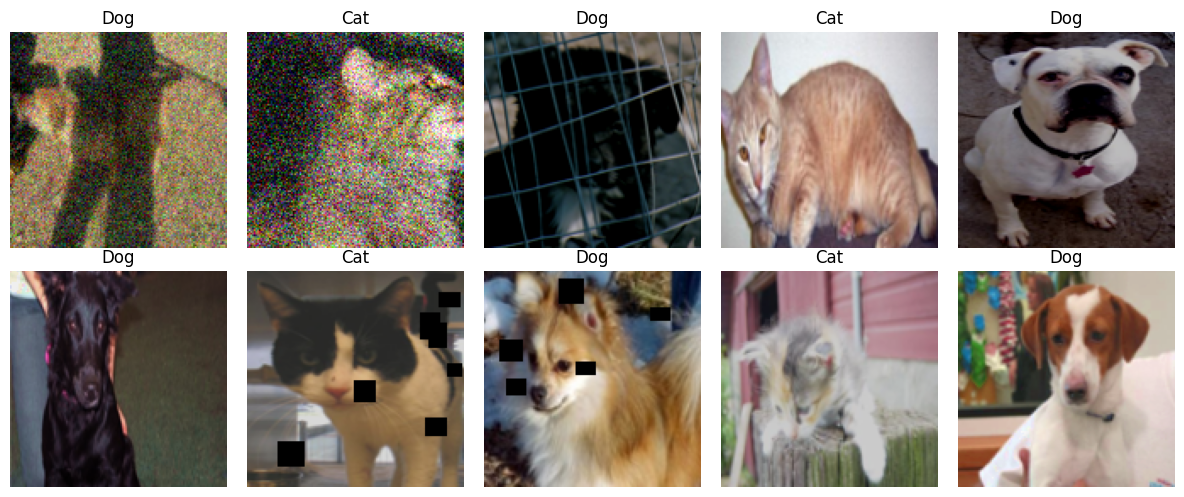

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]
    img = img.permute(1, 2, 0).numpy()  # Convertir de CxHxW à HxWxC
    img = (img * STD) + MEAN  # Dénormaliser
    img = np.clip(img, 0, 1)  # S'assurer que les valeurs sont entre 0 et 1
    axes[i].imshow(img)
    axes[i].set_title(f"{label_encoder.inverse_transform([label])[0]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Concevoir un bloc convolutionnel réutilisable

- Implémentez la classe `ConvLayer(in_channels, out_channels, kernel_size, stride=1, padding=1)` :
    - Enchaînez les opérations suivantes :
        - Convolution 2D (`nn.Conv2d`)
        - Normalisation de lot (`nn.BatchNorm2d`) : normalise les activations du mini-batch pour stabiliser et accélérer l’entraînement, tout en apportant un léger effet de régularisation -> conservez la taille
        - Activation ReLU (`nn.ReLU`)
        - Max pooling (`nn.MaxPool2d(2)`)
    - La méthode `forward(self, x)` applique ces opérations dans l'ordre.

In [ ]:
class ConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
        super(ConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

### Assembler le réseau de classification

- Définir la classe `Model(nn.Module)` :
    - Implémenter `__init__` et construire `self.features` comme une `nn.Sequential` de plusieurs blocs `ConvLayer` empilés :
        - `ConvLayer(3, 64, 3)`
        - `ConvLayer(64, 512, 3)`
        - Puis 6 blocs supplémentaires `ConvLayer(512, 512, 3)` pour approfondir la représentation.
    - Construire `self.classifier` comme une `nn.Sequential` :
        - `nn.AdaptiveAvgPool2d((1, 1))` pour réduire spatialement à une carte 1×1
        - `nn.Flatten()` pour passer en vecteur
        - `nn.Linear(512, 1)` pour la sortie binaire
        - `nn.Sigmoid()` pour convertir en probabilité
- Implémenter `forward(self, x)` :
    - Passer `x` dans `self.features` puis dans `self.classifier`
    - Retourner la sortie finale
- Instancier le modèle et le mettre sur le `device`
- Vérifier la sortie sur un lot factice :
    - Générer un tenseur d’entrée aléatoire avec `torch.randn`
    - Appeler `model(...)` et vérifier que la forme de sortie est `(BATCH_SIZE, 1)`


In [ ]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.features = nn.Sequential(
            ConvLayer(3, 64, 3),
            ConvLayer(64, 512, 3),
            ConvLayer(512, 512, 3),
            ConvLayer(512, 512, 3),
            ConvLayer(512, 512, 3),
            ConvLayer(512, 512, 3),
            ConvLayer(512, 512, 3),

        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = Model().to(device)
display(model)

Model(
  (features): Sequential(
    (0): ConvLayer(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvLayer(
      (conv): Conv2d(64, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvLayer(
      (conv): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): ConvLayer(
      (conv): Conv2

### Vérification de la sortie du modèle

Instanciez un tenseur aléatoire simulant un batch d'images avec la forme `(BATCH_SIZE, channels, height, width)`, passez-le au modèle sur le `device` approprié, puis vérifiez que la sortie possède bien la forme `(BATCH_SIZE, 1)` correspondant à une prédiction binaire par image.

In [ ]:
# Récupération des dimensions
sample_img, _ = full_dataset[0]
width, height, channels = sample_img.shape

# Vérification de la sortie du modèle
output = model(torch.randn(BATCH_SIZE, channels, width, height).to(device))
print(f'Sortie du modèle: {output.shape}')
assert output.shape == (BATCH_SIZE, 1), "La sortie du modèle doit avoir la forme (BATCH_SIZE, 1)"


Sortie du modèle: torch.Size([32, 1])


### Coder l'entrainement sur un mini-batch
Implémentez `train_batch(model, x, y, loss_fn, optimizer)`.


In [ ]:
def train_batch(model, x, y, loss_fn, optimizer):
    """Entraîne le modèle sur un mini-batch.

    Arguments:
    - model (torch.nn.Module): réseau à entraîner.
    - x (torch.Tensor): batch d'images (N, C, H, W) déjà sur le bon device.
    - y (torch.Tensor): cibles binaires (N, 1) en float sur le même device.
    - loss_fn (Callable): fonction de perte appliquée sur (predictions, y).
    - optimizer (torch.optim.Optimizer): optimiseur pour la mise à jour des poids.

    Retour:
    - float: valeur scalaire de la perte du batch.
    """
    model.train()
    predictions = model(x)
    batch_loss = loss_fn(predictions, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

### Mesurer l'accuracy sur un batch

Complétez la fonction `accuracy(model, x, y)` décorée par `@torch.no_grad()` :
- placez le modèle en évaluation
- calculez les probabilités
- seuiller à 0.5 pour obtenir les prédictions binaires
- retournez la proportion d'exemples correctement classés


In [ ]:
@torch.no_grad()
def accuracy(model, x, y):
    """Calcule l'accuracy sur un batch.

    Arguments:
    - model (torch.nn.Module): réseau à évaluer.
    - x (torch.Tensor): batch d'images (N, C, H, W) sur le bon device.
    - y (torch.Tensor): cibles binaires (N, 1) en float sur le même device.

    Retour:
    - float: proportion d'exemples correctement classés dans le batch.
    """
    model.eval()
    predictions = model(x)
    predicted_labels = (predictions >= 0.5).float()
    correct = (predicted_labels == y).sum().item()
    return correct / y.size(0)

### Calculer perte et accuracy sur un DataLoader

Implémentez `evaluate(model, data_loader, loss_fn)`.
- désactive le gradient
- parcourt l'ensemble des lots pour accumuler perte moyenne et accuracy (en utilisant le bon `device`) : utiliser `tqdm` pour afficher la progression
- renvoie les métriques moyennes globales

In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    """
    Évalue le modèle sur l'ensemble d'un DataLoader.

    Arguments:
    - model (torch.nn.Module): réseau à évaluer.
    - data_loader (torch.utils.data.DataLoader): DataLoader contenant les données à évaluer.
    - loss_fn (Callable): fonction de perte à utiliser.

    Retour:
    - tuple (float, float): perte moyenne et accuracy moyenne sur l'ensemble du DataLoader.
    """
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    total_samples = 0

    for x_batch, y_batch in tqdm(dataloader, desc="Evaluating"):
        x_batch = x_batch.to(device)
        y_batch = y_batch.float().unsqueeze(1).to(device)

        predictions = model(x_batch)
        batch_loss = loss_fn(predictions, y_batch)
        batch_accuracy = accuracy(model, x_batch, y_batch)

        batch_size = x_batch.size(0)
        total_loss += batch_loss.item() * batch_size
        total_accuracy += batch_accuracy * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_accuracy = total_accuracy / total_samples
    return avg_loss, avg_accuracy


### Initialisation

- Placez le modèle sur le `device`
- Choisissez la fonction de perte `nn.BCELoss` adaptée à une sortie sigmoïde et l'optimiseur `Adam`
- Fixez le nombre d'`epochs`
- Préparez des listes pour conserver les courbes de perte et d'accuracy (train et validation).  

In [ ]:
# model = Model() # pour reinitialiser le modèle au besoin
model = model.to(device)
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 40
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

### Boucle d'entraînement

Pour chaque époque :
- Passez en mode entraînement (`model.train()`) et itérez sur `train_loader` avec `tqdm` pour afficher la progression.  
- Pour chaque batch :
    - appelez `train_batch(model, x, y, loss_fn, optimizer)`   
    - Calculez l'accuracy et mettez à jour la barre `tqdm` avec `set_postfix(loss=..., acc=...)` pour un suivi fin.  
    - Agrégez les pertes et accuracies de tous les batches pour obtenir les moyennes d'époque et stockez-les dans `train_losses` et `train_accuracies`.  
- Passez en évaluation et appelez `evaluate(model, val_loader, loss_fn)` (avec `torch.no_grad()`) pour obtenir perte et accuracy sur l'ensemble de validation, puis enregistrez-les dans `val_losses` et `val_accuracies`.  
- Affichez un résumé (Train Loss / Train Accuracy / Val Loss / Val Accuracy).  

In [ ]:
for epoch in range(epochs):
    print("-" * 30)
    print(f"Epoch {epoch+1}/{epochs}")
    batch_losses = []
    batch_accuracies = []
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc="Train", leave=False)
    for batch_idx, (x_batch, y_batch) in loop:
        x_batch = x_batch.to(device)
        y_batch = y_batch.unsqueeze(-1).float().to(device)
        loss = train_batch(model, x_batch, y_batch, loss_fn, optimizer)
        batch_losses.append(loss)
        acc = accuracy(model, x_batch, y_batch)
        batch_accuracies.append(acc)
        loop.set_postfix(loss=f"{loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = sum(batch_losses) / len(batch_losses)
    avg_acc = sum(batch_accuracies) / len(batch_accuracies)
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)

    avg_val_loss, avg_val_acc = evaluate(model, val_loader, loss_fn)
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)
    print(f"Train Loss: {avg_loss:.4f}, Train Accuracy: {avg_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}")


------------------------------
Epoch 1/40


Train:   0%|          | 0/40 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.7859, Train Accuracy: 0.5133
Val Loss: 0.6822, Val Accuracy: 0.5125
------------------------------
Epoch 2/40


Train:   0%|          | 0/40 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.2353, Train Accuracy: 0.9195
Val Loss: 0.6308, Val Accuracy: 0.8000
------------------------------
Epoch 40/40


Train:   0%|          | 0/40 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.2559, Train Accuracy: 0.9070
Val Loss: 0.4778, Val Accuracy: 0.8094


### Visualiser l'évolution des performances

REMARQUE : on a utilisé ici un modèle completement "custom" sur un dataset tronqué, ce qui n'est pas optimal...

Tracez sur deux sous-graphiques l'évolution des pertes et des exactitudes pour l'entraînement et la validation en fonction des époques, légendez correctement les axes et appliquez `plt.tight_layout()` pour assurer une présentation lisible.

- Utilisez les listes `train_losses`, `val_losses`, `train_accuracies`, `val_accuracies` pour afficher les courbes d'apprentissage.
- Placez la perte (loss) sur le premier sous-graphe et l'exactitude (accuracy) sur le second.
- Ajoutez une légende, des titres et des labels d'axes pour chaque sous-figure.
- Utilisez `plt.tight_layout()` pour éviter le chevauchement des éléments graphiques.



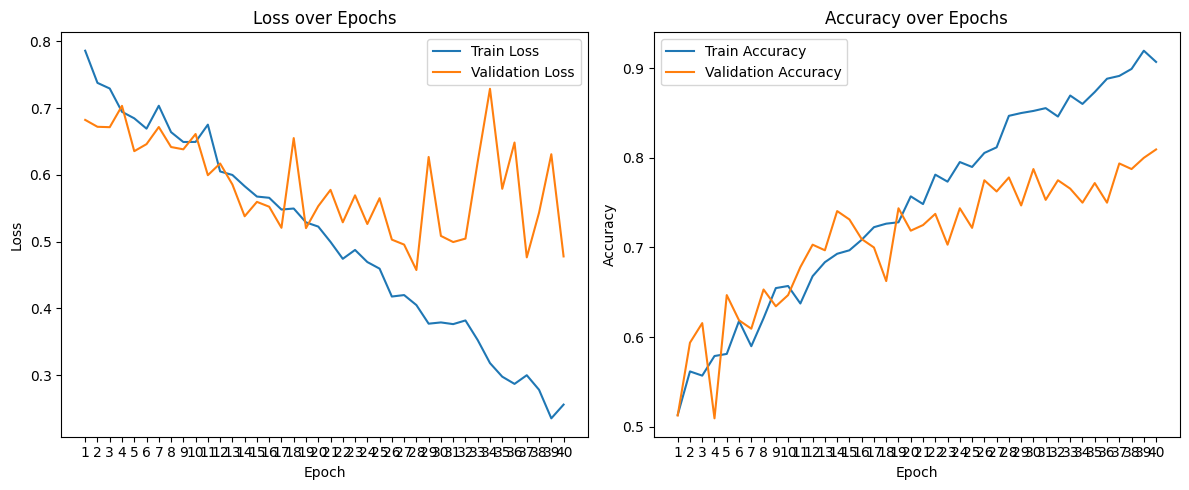

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_accuracies)+1, 1))
plt.legend()

plt.tight_layout()
plt.show()

### Définir le chemin de sauvegarde du modèle

Indiquez le nom de fichier qui servira à stocker les poids appris du réseau, de sorte à pouvoir réutiliser l'état entraîné ultérieurement.


In [ ]:
model_weighths_dir = "../model_weights/" # mettez le votre
model_name = "06_custom_cats_dogs_model.pth"
weights_path = os.path.join(model_weighths_dir, model_name)

### Sauvegarder les poids du modèle entraîné

Préparez l'appel à `torch.save(model.state_dict(), weights_path)` assorti d'un message de confirmation afin de sérialiser les paramètres du modèle ; laissez ces instructions commentées si vous souhaitez éviter l'écriture automatique lors des tests.


In [ ]:
# torch.save(model.state_dict(), weights_path) # commenté pour éviter d'écraser les poids déjà enregistrés
print(f"Model weights saved to {weights_path}")

Model weights saved to ../model_weights/06_custom_cats_dogs_model.pth


### Recharger un modèle sauvegardé

Chargez les poids depuis `filename` en tenant compte du `device`, appliquez-les au modèle puis affichez un message confirmant que l'état entraîné est correctement restauré.


In [ ]:
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {weights_path}")

Model weights loaded from ../model_weights/06_custom_cats_dogs_model.pth


### Affichage de predictions sur des images du jeu de test

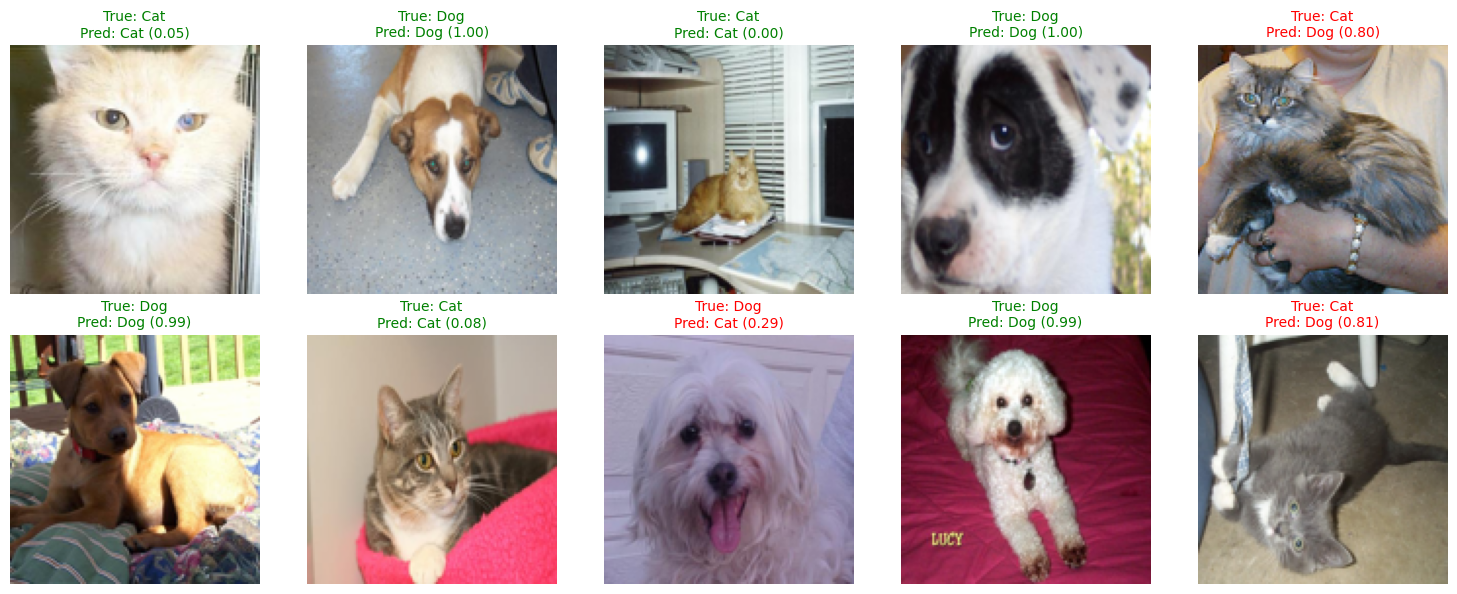

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

model.eval()
with torch.no_grad():
    for i in range(10):
        idx = random.randint(0, len(test_dataset) - 1)
        img, true_label = test_dataset[idx]

        # Prédiction
        img_tensor = img.unsqueeze(0).to(device)
        pred_prob = model(img_tensor).cpu().item()
        pred_label = int(pred_prob >= 0.5)

        # Dénormaliser l'image pour l'affichage
        img_display = img.permute(1, 2, 0).numpy()
        img_display = (img_display * STD) + MEAN
        img_display = np.clip(img_display, 0, 1)

        # Afficher l'image
        axes[i].imshow(img_display)

        # Préparer le titre avec la vraie classe et la prédiction
        true_class = label_encoder.inverse_transform([true_label])[0]
        pred_class = label_encoder.inverse_transform([pred_label])[0]

        # Couleur du titre : vert si correct, rouge si incorrect
        color = 'green' if pred_label == true_label else 'red'

        axes[i].set_title(f"True: {true_class}\nPred: {pred_class} ({pred_prob:.2f})",
                         color=color, fontsize=10)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

### Utiliser le modèle sur le jeu de test

Collectez les probabilités prédites sur `test_loader`, transformez-les en classes à l'aide d'un seuil à 0.5, et stockez les résultats dans des listes nommées :

- **`all_probs`** : probabilités continues prédites par le modèle pour chaque image du jeu de test (valeurs entre 0 et 1)
- **`all_preds`** : classes prédites binaires obtenues en appliquant un seuil à 0.5 sur `all_probs` (0 pour Chat, 1 pour Chien)
- **`all_labels`** : vraies étiquettes binaires du jeu de test (0 pour Chat, 1 pour Chien)

In [ ]:
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        probs = model(x_batch).cpu().numpy().flatten()
        labels = y_batch.cpu().numpy().flatten()

        all_probs.extend(probs.tolist())
        all_labels.extend(labels.tolist())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)
all_labels = np.array(all_labels).astype(int)

print(f"all_probs shape: {all_probs.shape}")
print(f"all_preds shape: {all_preds.shape}")
print(f"all_labels shape: {all_labels.shape}")
print(f"\nFirst 10 probabilities: {all_probs[:10]}")
print(f"First 10 predictions: {all_preds[:10]}")
print(f"First 10 true labels: {all_labels[:10]}")

all_probs shape: (400,)
all_preds shape: (400,)
all_labels shape: (400,)

First 10 probabilities: [0.15627111 0.03292492 0.99712628 0.06517515 0.05542715 0.71646619
 0.99716479 0.00218159 0.01881921 0.57803947]
First 10 predictions: [0 0 1 0 0 1 1 0 0 1]
First 10 true labels: [0 0 1 0 0 1 1 0 0 1]


### Afficher le rapport de classification sur le jeu de test

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_, digits=4))

print(f"\nAccuracy (sklearn): {accuracy_score(all_labels, all_preds):.4f}")


Classification Report:
              precision    recall  f1-score   support

         Cat     0.8141    0.8100    0.8120       200
         Dog     0.8109    0.8150    0.8130       200

    accuracy                         0.8125       400
   macro avg     0.8125    0.8125    0.8125       400
weighted avg     0.8125    0.8125    0.8125       400


Accuracy (sklearn): 0.8125


### Afficher la matrice de confusion

La cellule suivante affiche la matrice de confusion du modèle sur le jeu de test.  
Elle utilise la fonction `confusion_matrix` de scikit-learn pour calculer le nombre de prédictions correctes et incorrectes pour chaque classe, puis visualise ces résultats avec `seaborn.heatmap`.  
Les axes du graphique indiquent les classes réelles (True) et prédites (Predicted), et chaque case contient le nombre d'exemples correspondants.  
Cela permet d'évaluer la qualité de la classification et d'identifier les éventuelles confusions entre "Cat" et "Dog".

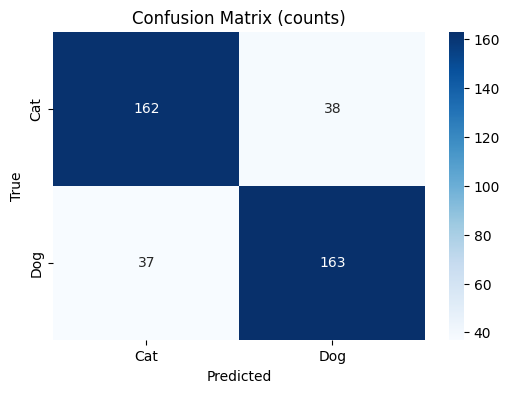

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (counts)')
plt.show()

### Approfondir l'expérimentation

- Étudier l'impact de la réduction ou de l'accroissement du nombre de données d'entrainement.
- Explorer de nouvelles pistes : ajustez l'architecture, modifiez les hyperparamètres, introduisez de la régularisation ou comparez d'autres stratégies d'augmentation de données.